In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv("london_merged.csv")
data['timestamp'] = pd.to_datetime(data['timestamp'])
data['year'] = data['timestamp'].dt.year
data['month'] = data['timestamp'].dt.month
data['day'] = data['timestamp'].dt.day
data['hour'] = data['timestamp'].dt.hour
data['minute'] = data['timestamp'].dt.minute

# print(data.head())

#Lets have the data with na and others filled with mean data, and lets fit the model to predict the season
X = data.iloc[:,1:9].add(data.iloc[:, 10:],fill_value = 0 )
Y = data.iloc[:, 9]

indices = np.random.permutation(len(Y))
X = X.iloc[indices]
Y = Y.iloc[indices]

In [5]:
class LinearRegression:
    def __init__(self, thetas, X_train, X_test, Y_train, Y_test, alpha=0.001, epochs=1000):
        self.thetas = thetas
        self.X_test = X_test
        self.X_train = X_train
        self.Y_test = Y_test
        self.Y_train = Y_train
        self.alpha = alpha
        self.epochs = epochs
        
    def predict(self, X):
        return X @ self.thetas
        
    def fit(self):
        for epoch in range(self.epochs):
            Y_hat = self.predict(self.X_train)
            
            if epoch % 100 == 0:
                print(f"After {epoch} iterations:")
                print("Thetas: ",self.thetas)
                print("Mean Squared Error: ",self.mse(self.Y_train, Y_hat))
                
            self.thetas -= self.alpha * self.gradient()

    def gradient(self):
        m = len(self.X_train)
        return (1/m) * np.dot(self.X_train.T, (self.predict(self.X_train) - self.Y_train))
    
    def mse(self, Y, Y_expected):
        return np.mean((Y - Y_expected) ** 2)

In [8]:
split = round(len(X)*0.75)
X_train = X[:split].to_numpy()
X_test = X[split:].to_numpy()
Y_train = Y[:split].to_numpy()
Y_test = Y[split:].to_numpy()
#Practically this is the best possible combination for the given data set
thetas = np.random.rand(X_train.shape[1])*0.001
model = LinearRegression(thetas,X_train,X_test,Y_train,Y_test,0.0000001,100000)
model.fit()
print("Expected: ______ Got:")
print(Y_test, model.predict(X_test))


After 0 iterations:
Thetas:  [1.02965269e-04 2.47492659e-04 2.40039149e-04 9.71422549e-04
 6.84658102e-04 7.95536717e-04 8.57209202e-04 1.28084804e-04
 6.49007806e-05 1.91788212e-04 2.00244029e-04 3.96286444e-04
 4.19684379e-04]
Mean Squared Error:  1.4764770354760972
After 100 iterations:
Thetas:  [-1.20726305e-04  2.49349322e-04  2.43984201e-04  1.02325282e-03
  6.84611050e-04  7.95496680e-04  8.57209202e-04  1.37428903e-04
  5.16455375e-05  1.75397588e-04  2.02942556e-04  4.00607934e-04
  7.61745467e-04]
Mean Squared Error:  1.2255923573697527
After 200 iterations:
Thetas:  [-1.20486172e-04  2.48495395e-04  2.46852053e-04  1.06011690e-03
  6.84557573e-04  7.95392677e-04  8.57209202e-04  1.45740134e-04
  3.71174530e-05  1.58003632e-04  2.05020093e-04  4.02560140e-04
  7.60427797e-04]
Mean Squared Error:  1.2252002500367267
After 300 iterations:
Thetas:  [-1.20200113e-04  2.47643447e-04  2.49724339e-04  1.09691366e-03
  6.84504085e-04  7.95288746e-04  8.57209202e-04  1.54050062e-04
  

In [10]:
print(Y_train[20])
print(model.predict(np.array([6.800e+01, 1.400e+01, 1.000e+00, 8.100e+01, 0.000e+00, 0.000e+00, 0.000e+00,
 3.000e+00, 6.000e+00, 3.000e+00, 4.000e+00, 1.300e+01, 2.016e+03])))

2.0
1.6997040999254944


In [25]:
X = data.iloc[:,2:]
Y = data.iloc[:,1]
split = round(len(X)*0.75)
X_train = X[:split].to_numpy()
X_test = X[split:].to_numpy()
Y_train = Y[:split].to_numpy()
Y_test = Y[split:].to_numpy()
#Practically this is never converges hence we cant fit a linear model to this data
thetas = np.random.rand(X_train.shape[1])*0.0000000001
model = LinearRegression(thetas,X_train,X_test,Y_train,Y_test,0.000000000000001,1000)
model.fit()
print("Expected: ______ Got:")
print(Y_test, model.predict(X_test))


After 0 iterations:
Thetas:  [6.28352713e-11 1.86754253e-11 7.09534823e-11 8.11937587e-11
 3.26948701e-11 2.83615688e-11 1.35943386e-11 7.99083690e-11
 9.48288773e-11 6.01791315e-11 1.99553176e-11 9.00972382e-11
 3.84384635e-11]
Mean Squared Error:  2315590.5979506387
After 100 iterations:
Thetas:  [1.57845245e-09 1.44786135e-09 7.29259993e-09 1.98779131e-09
 2.98283330e-10 3.01012468e-11 4.05874256e-11 2.15505023e-10
 2.22109150e-07 6.98910348e-10 1.71986893e-09 1.58944279e-09
 3.84384635e-11]
Mean Squared Error:  2315589.6108282176
After 200 iterations:
Thetas:  [3.09406910e-09 2.87704680e-09 1.45142432e-08 3.89438813e-09
 5.63871665e-10 3.18409237e-11 6.75804999e-11 3.51101616e-10
 4.44123381e-07 1.33764132e-09 3.41978184e-09 3.08878783e-09
 3.84384635e-11]
Mean Squared Error:  2315588.623706599
After 300 iterations:
Thetas:  [4.60968521e-09 4.30623175e-09 2.17358832e-08 5.80098421e-09
 8.29459874e-10 3.35805996e-11 9.45735613e-11 4.86698148e-10
 6.66137522e-07 1.97637204e-09 5.1196

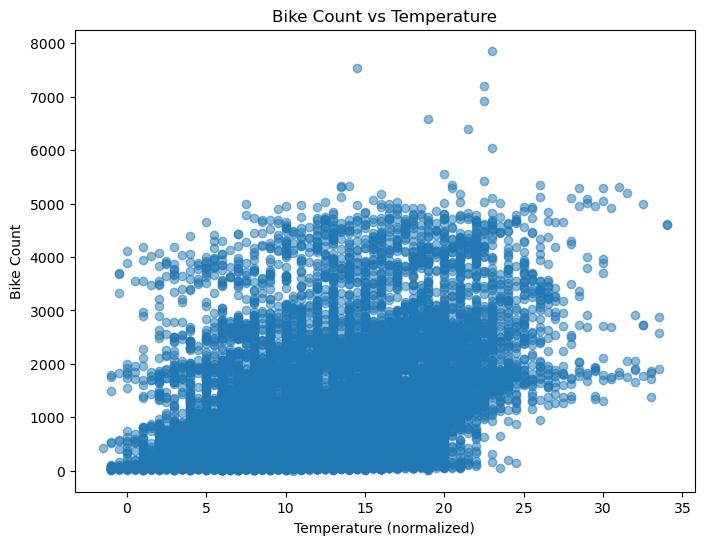

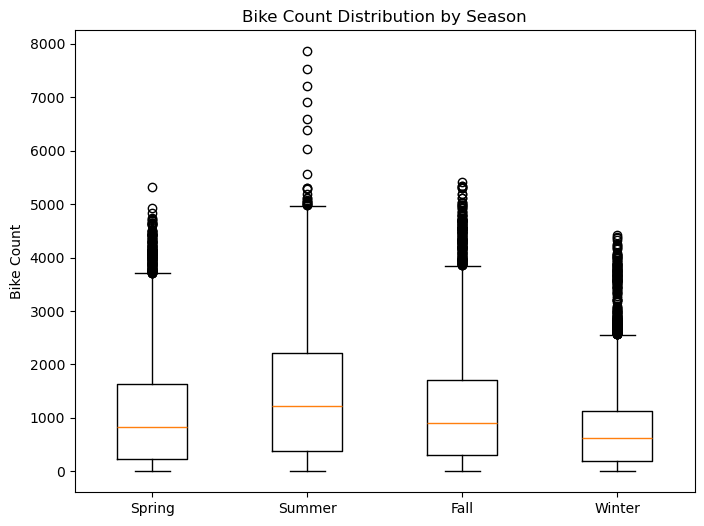

In [35]:
# visualize_data.py
import pandas as pd
import matplotlib.pyplot as plt

# Load your dataset
data = pd.read_csv("london_merged.csv")

# Plot bike count vs temperature
plt.figure(figsize=(8, 6))
plt.scatter(data['t1'], data['cnt'], alpha=0.5)
plt.title('Bike Count vs Temperature')
plt.xlabel('Temperature (normalized)')
plt.ylabel('Bike Count')
plt.show()

# Plot bike count vs season
plt.figure(figsize=(8, 6))
plt.boxplot([data[data['season'] == s]['cnt'] for s in sorted(data['season'].unique())],
            labels=['Spring', 'Summer', 'Fall', 'Winter'])
plt.title('Bike Count Distribution by Season')
plt.ylabel('Bike Count')
plt.show()

